# 보고서 「중국 허브화와 세계 교역 네트워크, 1995–2024」 — 분석 파이썬 코드

이 노트북은 보고서(`중국허브화와_세계교역네트워크.md`)의 표 수치와 그림 여섯 장을 만든다. 저장소 안 어느 폴더에서 열어도 되며, 루트의 `config/settings.py`를 찾아 경로를 잡는다.

입력은 `scripts/01`~`04`가 만든 DuckDB(`data/processed/baci_net.duckdb`)다. 네트워크 지표 표 `mart_net_metrics`에 HS2·HS4 수준의 변형 `w1m`, `w1m_bal`, `w1m_bal_xchn`이 있어야 한다. `scripts/04_compute_metrics.py --level hs4 --workers 6`으로 앞의 둘이, `--variants w1m_bal_xchn`을 더하면 중국 제외 변형이 만들어진다. 엣지 표 `edge_hs4`와 고정 국가군 `dim_fixed_country`도 쓴다.

그림은 이 폴더의 `img/`에, 표는 `outputs/`에 저장된다. `outputs/`는 저장소에 올리지 않는다. 마지막 셀은 보고서가 인용한 수치를 다시 계산한 값과 대조하고, 하나라도 어긋나면 멈춘다.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from IPython.display import display

# 저장소 루트를 찾는다. 이 노트북은 저장소 안 어느 폴더에서 열어도 된다.
ROOT = Path.cwd().resolve()
while not (ROOT / "config" / "settings.py").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("저장소 루트(config/settings.py)를 찾지 못했다")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from config.settings import DB_PATH

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
REGION_HEX = {"Asia": "#2F7FD1", "America": "#2A8F55", "Middle East": "#8F62D8", "Europe": "#B8862A",
              "Oceania": "#1F9C90", "Africa": "#C95A4B", "Other": "#7C8593"}
REGION_KO = {"Asia": "아시아", "America": "아메리카", "Middle East": "중동", "Europe": "유럽", "Oceania": "오세아니아", "Africa": "아프리카"}
con = duckdb.connect(str(DB_PATH), read_only=True)

import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

HERE = ROOT / "analysis" / "중국허브화"
IMG = HERE / "img"; IMG.mkdir(exist_ok=True)
OUT = HERE / "outputs"; OUT.mkdir(exist_ok=True)
print("저장소:", ROOT)
print("DB:", DB_PATH, "있음" if DB_PATH.exists() else "없음")
print(con.execute("SELECT level, variant, count(*) AS 행 FROM mart_net_metrics GROUP BY 1, 2 ORDER BY 1, 2").df())

저장소: C:\Work\Projects\UNComtraade
DB: C:\Work\Projects\UNComtraade\data\processed\baci_net.duckdb 있음
    level            variant      행
0     hs2                raw   2880
1     hs2                w1m   2880
2     hs2            w1m_bal   2880
3     hs2       w1m_bal_xchn   2880
4     hs4                raw  37083
5     hs4                w1m  36801
6     hs4            w1m_bal  36789
7     hs4       w1m_bal_real  36724
8     hs4       w1m_bal_xchn  36733
9     hs4  w1m_bal_xchn_real  36642
10  total                raw     30
11  total                w1m     30
12  total            w1m_bal     30
13  total       w1m_bal_xchn     30


## §2 전체 지표의 30년

### HS4 호의 중위값, 1995년과 2024년

보고서 II장 표의 앞 두 열이다. 고정 207개국·100만 달러 이상 흐름(`w1m_bal`)과 그 중국 제외 변형(`w1m_bal_xchn`), 그리고 임곗값을 1995년 불변가격 100만 달러로 해마다 CPI만큼 올린 실질 변형(`_real`)의 호별 중위값이다.

In [2]:
COLS = ["n_nodes", "density", "reciprocity", "hhi_exp", "top5_exp_share", "gini_out_strength",
        "centralization_out", "clustering_avg", "modularity", "max_kcore", "intra_region_share"]
mall = con.execute("SELECT * FROM mart_net_metrics WHERE level='hs4' AND variant IN ('w1m_bal', 'w1m_bal_xchn', 'w1m_bal_real', 'w1m_bal_xchn_real')").df()
med = mall[mall.t.isin([1995, 2024])].groupby(["variant", "t"])[COLS].median().T
med.to_csv(OUT / "s2_HS4_중위값.csv", encoding="utf-8-sig")
med.round(3)

variant            w1m_bal         w1m_bal_real         w1m_bal_xchn         w1m_bal_xchn_real        
t                     1995    2024         1995    2024         1995    2024              1995    2024
n_nodes             50.000  81.000       50.000  66.000       48.000  69.000            48.000  56.000
density              0.063   0.050        0.063   0.052        0.063   0.055             0.063   0.058
reciprocity          0.156   0.154        0.156   0.138        0.161   0.164             0.161   0.146
hhi_exp              0.142   0.145        0.142   0.155        0.145   0.112             0.145   0.121
top5_exp_share       0.717   0.697        0.717   0.718        0.727   0.635             0.727   0.662
gini_out_strength    0.826   0.878        0.826   0.863        0.825   0.839             0.825   0.818
centralization_out   0.433   0.583        0.433   0.549        0.430   0.433             0.430   0.409
clustering_avg       0.398   0.463        0.398   0.423        0.387   0.419             0.387   0.377
modularity           0.348   0.325        0.348   0.329        0.347   0.367             0.347   0.373
max_kcore            6.000   8.000        6.000   6.000        5.000   7.000             5.000   6.000
intra_region_share   0.614   0.538        0.614   0.542        0.617   0.600             0.617   0.605

### 품목 패널 회귀 — 추세와 사건

표본은 30년 전부 관측된 품목(HS4 1,203개 호)이다. 품목 고정효과(product fixed effects)는 품목 안의 평균을 빼서 흡수하고, 표준오차는 품목 군집(clustered by product)으로 잡는다.

- 모형 A, 선형추세: $`y_{pt} = a_p + b \cdot \tau_t + e_{pt}`$, $`\tau_t = (t - 1995)/10`$. 추세 $`b`$를 표준편차로 나눈 값(β/SD)이 보고서 §2·§4 표의 수치다.
- 모형 B, 구간별 추세: 2009·2018·2020년의 수준 점프와 그 뒤 기울기 변화를 더한다.
- 모형 C, 연도 고정효과: 1995년을 0으로 둔 연도별 효과 $`\hat\gamma_t`$와 그 95% 신뢰구간. 그림 1·그림 4가 이것이다. 연도별 변화 $`\hat\gamma_t - \hat\gamma_{t-1}`$의 z값을 29개 연도 사이에서 순위 매긴다.

In [3]:
METRICS = {"log_n_nodes": "활성 국가 수(로그)", "density": "밀도", "reciprocity": "호혜성", "hhi_exp": "수출 HHI",
           "top5_exp_share": "상위 5개국 점유율", "gini_out_strength": "수출 지니", "centralization_out": "수출 차수 중심화",
           "clustering_avg": "군집계수", "modularity": "모듈성", "max_kcore": "최대 k-코어", "intra_region_share": "역내 비중"}
EVENTS = {"2009": 2009, "2018": 2018, "2020": 2020}
T0 = 1995
SEC = con.execute("SELECT DISTINCT hs2, section_name FROM dim_product").df()


def stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""


def within(df, cols, by="code", w=None):
    """품목 안의 평균(가중이면 가중평균)을 뺀다."""
    out = df[cols].copy()
    if w is None:
        return out - df.groupby(by)[cols].transform("mean")
    ww = df[w]
    for c in cols:
        out[c] = df[c] - (df[c] * ww).groupby(df[by]).transform("sum") / ww.groupby(df[by]).transform("sum")
    return out


def fit(y, X, groups, w=None):
    model = sm.OLS(y, X) if w is None else sm.WLS(y, X, weights=w)
    return model.fit(cov_type="cluster", cov_kwds={"groups": groups})


def run_panel(level, variant, weighted=False, fig_name=None):
    tag = f"{level}_{variant}" + ("_w" if weighted else "")
    m = con.execute("SELECT * FROM mart_net_metrics WHERE level = ? AND variant = ?", [level, variant]).df()
    m["hs2"] = m.code.str[:2]
    m = m.merge(SEC, on="hs2", how="left")
    m["log_n_nodes"] = np.log(m.n_nodes)
    m["max_kcore"] = m.max_kcore.astype(float)
    full = m.groupby("code").t.nunique()
    m = m[m.code.isin(full[full == full.max()].index)].sort_values(["code", "t"]).reset_index(drop=True)
    m["tt"] = (m.t - T0) / 10.0
    m["gid"] = pd.factorize(m.code)[0]
    wcol = None
    if weighted:
        m["w"] = m.groupby("code").total_value.transform("mean")
        m["w"] = m.w / m.w.mean()
        wcol = "w"
    for k, ty in EVENTS.items():
        m[f"post{k}"] = (m.t >= ty).astype(float)
        m[f"post{k}_tt"] = m[f"post{k}"] * (m.t - ty) / 10.0
    year_cols = [f"y{t}" for t in range(T0 + 1, int(m.t.max()) + 1)]
    for t in range(T0 + 1, int(m.t.max()) + 1):
        m[f"y{t}"] = (m.t == t).astype(float)
    rowsA, rowsB, rowsC, taus = [], [], [], {}
    for met, label in METRICS.items():
        d = m.dropna(subset=[met])
        sd = d[met].std(); g = d.gid.values; w = d[wcol].values if wcol else None
        Z = within(d, [met, "tt"], w=wcol); rA = fit(Z[met], Z[["tt"]], g, w)
        rowsA.append(dict(metric=met, 지표=label, 품목=d.code.nunique(), 평균=d[met].mean(), SD=sd,
                          beta_10년=rA.params.tt, se=rA.bse.tt, p=rA.pvalues.tt, beta_SD=rA.params.tt / sd))
        xb = ["tt"] + [f"post{e}" for e in EVENTS] + [f"post{e}_tt" for e in EVENTS]
        Z = within(d, [met] + xb, w=wcol); rB = fit(Z[met], Z[xb], g, w)
        rowB = dict(metric=met, 지표=label, 기본추세=rB.params.tt, 기본추세_p=rB.pvalues.tt)
        for e in EVENTS:
            rowB[f"점프{e}"] = rB.params[f"post{e}"]; rowB[f"점프{e}_p"] = rB.pvalues[f"post{e}"]
            rowB[f"기울기{e}"] = rB.params[f"post{e}_tt"]; rowB[f"기울기{e}_p"] = rB.pvalues[f"post{e}_tt"]
        rowsB.append(rowB)
        Z = within(d, [met] + year_cols, w=wcol); rC = fit(Z[met], Z[year_cols], g, w)
        tau = pd.Series(np.r_[0.0, rC.params.values], index=range(T0, T0 + len(year_cols) + 1))
        Vf = np.zeros((len(tau), len(tau))); Vf[1:, 1:] = rC.cov_params().values
        taus[met] = (tau, np.sqrt(np.diag(Vf)), sd, label)
        for i, t in enumerate(tau.index[1:], start=1):
            c = np.zeros(len(tau)); c[i] = 1; c[i - 1] = -1
            dv, dse = c @ tau.values, np.sqrt(c @ Vf @ c)
            rowsC.append(dict(metric=met, 지표=label, t=int(t), 변화=dv, z=dv / dse if dse > 0 else np.nan))
    A, B, C = pd.DataFrame(rowsA), pd.DataFrame(rowsB), pd.DataFrame(rowsC)
    C["순위"] = C.groupby("metric").z.transform(lambda s: s.abs().rank(ascending=False)).astype(int)
    out = OUT / f"panel_{tag}"; out.mkdir(exist_ok=True)
    A.to_csv(out / "A_trend.csv", index=False, encoding="utf-8-sig")
    B.to_csv(out / "B_piecewise.csv", index=False, encoding="utf-8-sig")
    C.to_csv(out / "C_year_changes.csv", index=False, encoding="utf-8-sig")
    if fig_name:
        fig, axes = plt.subplots(3, 4, figsize=(18, 11))
        axes = list(axes.flat)
        for ax, (met, (tau, se, sd, label)) in zip(axes, taus.items()):
            ax.plot(tau.index, tau.values, color="k", lw=2)
            ax.fill_between(tau.index, tau.values - 1.96 * se, tau.values + 1.96 * se, alpha=0.25)
            ax.axhline(0, color="gray", lw=0.6)
            for ty in EVENTS.values():
                ax.axvline(ty, color="gray", ls=":", lw=0.8)
            ax.set_title(f"{label} (SD={sd:.3f})")
        for ax in axes[len(taus):]:
            ax.axis("off")
        fig.suptitle(f"연도 고정효과(1995=0)와 95% 신뢰구간, 품목 군집 표준오차 — {tag}")
        fig.tight_layout()
        fig.savefig(IMG / fig_name, dpi=110, facecolor="white")
        plt.show()
    print(f"{tag}: 품목 {m.code.nunique()}개 × {m.t.nunique()}년 = {len(m):,}행")
    return dict(A=A, B=B, C=C)

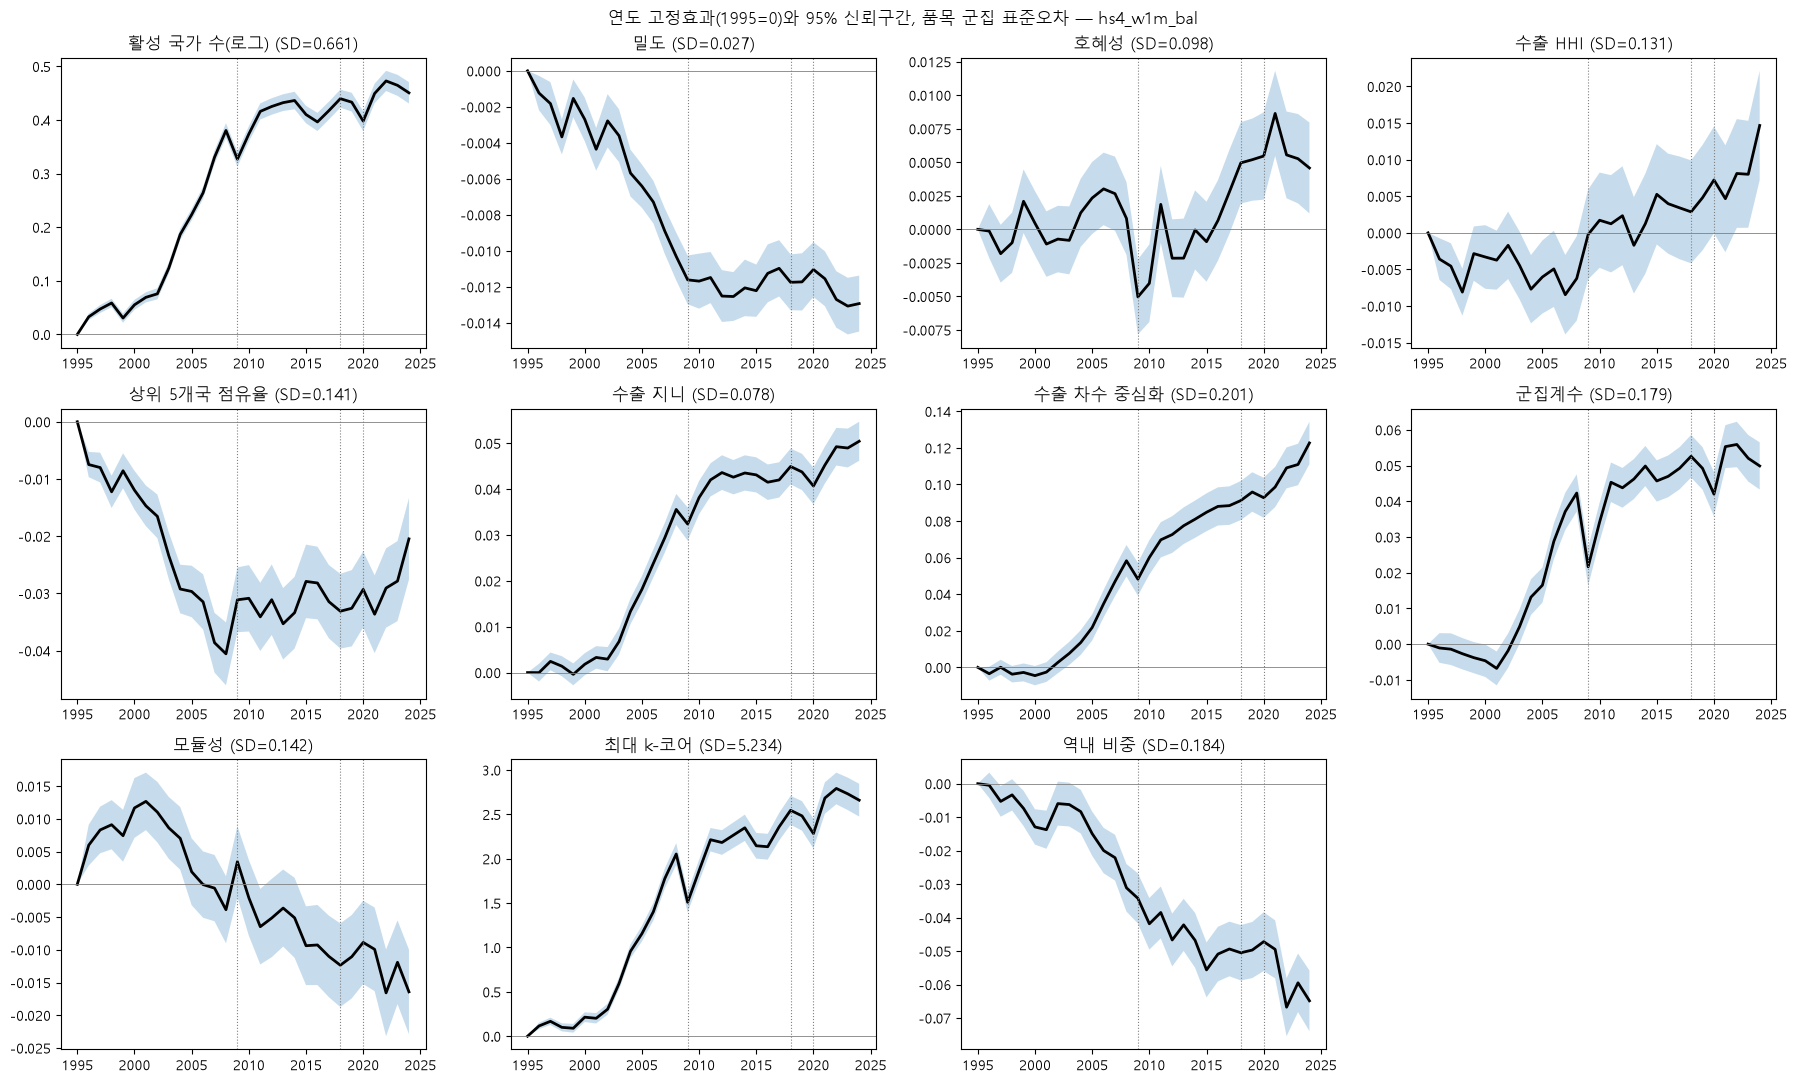

hs4_w1m_bal: 품목 1203개 × 30년 = 36,090행


hs4_w1m: 품목 1204개 × 30년 = 36,120행


hs4_raw: 품목 1216개 × 30년 = 36,480행


hs4_w1m_bal_real: 품목 1198개 × 30년 = 35,940행


hs2_w1m_bal: 품목 96개 × 30년 = 2,880행


hs4_w1m_bal_w: 품목 1203개 × 30년 = 36,090행


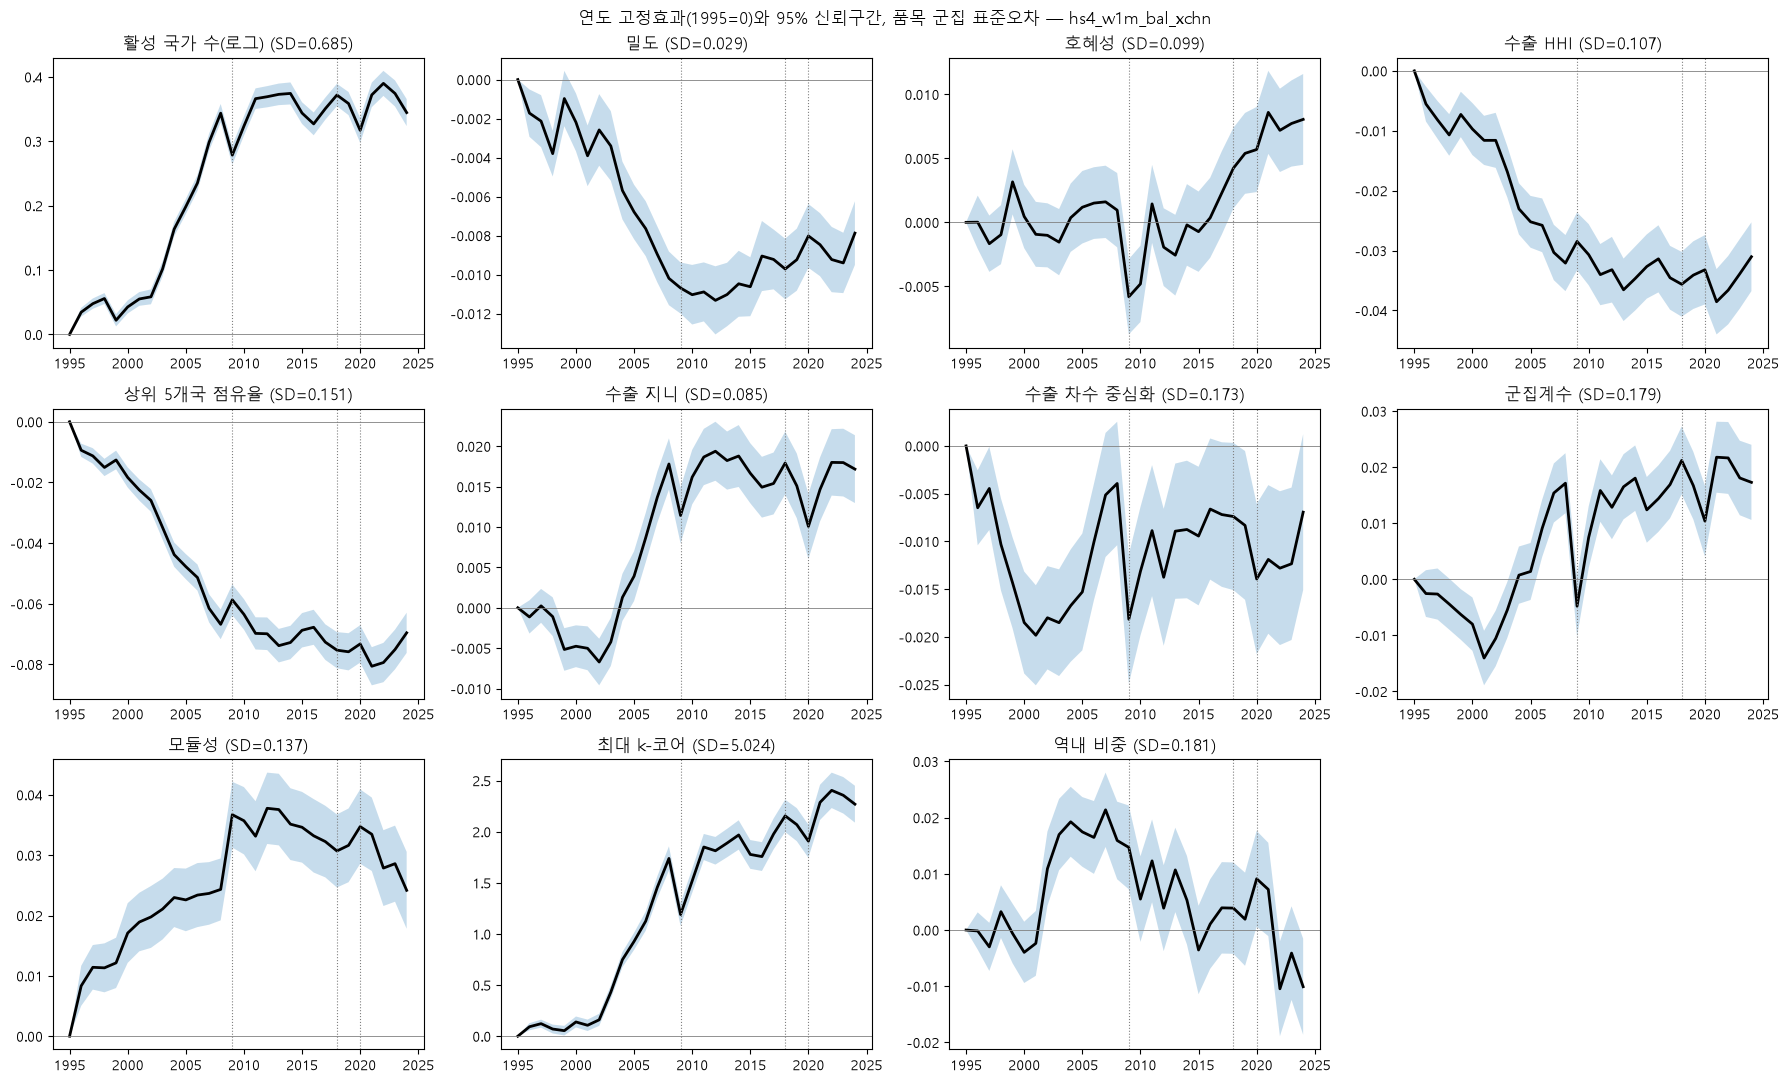

hs4_w1m_bal_xchn: 품목 1198개 × 30년 = 35,940행


hs2_w1m_bal_xchn: 품목 96개 × 30년 = 2,880행


hs4_w1m_bal_xchn_real: 품목 1186개 × 30년 = 35,580행


In [4]:
SPECS = [("hs4", "w1m_bal", False, "fig1_연도효과_중국포함.png"),
         ("hs4", "w1m", False, None),
         ("hs4", "raw", False, None),
         ("hs4", "w1m_bal_real", False, None),
         ("hs2", "w1m_bal", False, None),
         ("hs4", "w1m_bal", True, None),
         ("hs4", "w1m_bal_xchn", False, "fig4_연도효과_중국제외.png"),
         ("hs2", "w1m_bal_xchn", False, None),
         ("hs4", "w1m_bal_xchn_real", False, None)]
RES = {}
for level, variant, weighted, fig_name in SPECS:
    RES[f"{level}_{variant}" + ("_w" if weighted else "")] = run_panel(level, variant, weighted, fig_name)

### 추세 비교 — 보고서 §2와 §4의 표

10년당 추세를 표준편차로 나눈 값(β/SD)과 유의수준. 주 사양은 `hs4_w1m_bal`, 견고성 사양은 노드를 고정하지 않은 `hs4_w1m`, 임곗값 없는 `hs4_raw`, 실질 임곗값 `hs4_w1m_bal_real`(1995년 불변 100만 달러, 미국 CPI-U), HS2 수준, 총액 가중(`_w`)이다. `_xchn`은 중국 제외.

In [5]:
cmp = pd.DataFrame({tag: r["A"].set_index("지표").apply(lambda x: f"{x.beta_SD:+.2f}{stars(x.p)}", axis=1) for tag, r in RES.items()})
cmp.to_csv(OUT / "s2_s4_추세비교.csv", encoding="utf-8-sig")
cmp

,hs4_w1m_bal,hs4_w1m,hs4_raw,hs4_w1m_bal_real,hs2_w1m_bal,hs4_w1m_bal_w,hs4_w1m_bal_xchn,hs2_w1m_bal_xchn,hs4_w1m_bal_xchn_real
지표,,,,,,,,,
활성 국가 수(로그),+0.27***,+0.27***,+0.25***,+0.16***,+0.27***,+0.18***,+0.21***,+0.20***,+0.10***
밀도,-0.17***,-0.19***,+0.27***,-0.13***,+0.20***,+0.07*,-0.11***,+0.25***,-0.07***
호혜성,+0.02***,+0.00,+0.23***,-0.02***,+0.12***,+0.09***,+0.03***,+0.11***,-0.02***
수출 HHI,+0.04***,+0.05***,+0.10***,+0.07***,+0.04,+0.05*,-0.11***,-0.10***,-0.06***
상위 5개국 점유율,-0.06***,-0.05***,+0.02**,-0.01,-0.03,-0.01,-0.18***,-0.22***,-0.13***
수출 지니,+0.26***,+0.27***,+0.10***,+0.18***,+0.13***,+0.12***,+0.10***,-0.02,+0.01
수출 차수 중심화,+0.24***,+0.22***,+0.29***,+0.20***,+0.38***,+0.25***,+0.00,+0.11***,-0.03***
군집계수,+0.13***,+0.12***,+0.17***,+0.06***,+0.21***,+0.16***,+0.06***,+0.13***,-0.02**
모듈성,-0.06***,-0.05***,-0.02***,-0.06***,-0.06**,-0.11***,+0.06***,+0.08***,+0.07***


### 사건 연도의 연간 변화 — 모형 C

2009·2018·2020년의 연간 변화 z값과, 그 크기가 29개 연도 변화 가운데 몇 번째인지(1이 가장 큼).

In [6]:
ev = []
for tag in ["hs4_w1m_bal", "hs4_w1m_bal_xchn"]:
    C = RES[tag]["C"]
    for y in (2009, 2018, 2020):
        s = C[C.t == y].set_index("지표")
        ev.append(pd.DataFrame({(tag, y): s.apply(lambda x: f"{x.z:+.1f} ({x.순위})", axis=1)}))
pd.concat(ev, axis=1)

hs4_w1m_bal                         hs4_w1m_bal_xchn                      
                   2009        2018        2020             2009       2018       2020
지표                                                                                    
활성 국가 수(로그)   -18.9 (5)   +8.7 (16)  -12.8 (11)        -20.3 (1)  +8.0 (16)  -13.7 (8)
밀도             -4.8 (3)   -1.7 (19)   +2.1 (16)        -1.1 (20)  -1.2 (19)   +2.9 (9)
호혜성            -8.2 (2)    +3.2 (8)   +0.4 (25)         -8.3 (2)   +2.7 (9)  +0.4 (25)
수출 HHI         +4.8 (2)   -0.5 (24)   +2.0 (13)         +2.7 (8)  -1.1 (24)  +0.7 (26)
상위 5개국 점유율     +8.2 (1)   -1.8 (22)   +3.2 (15)         +6.7 (6)  -2.7 (21)  +2.2 (22)
수출 지니         -4.4 (11)   +4.0 (13)   -4.9 (10)         -7.9 (1)  +3.4 (12)   -6.0 (6)
수출 차수 중심화      -5.9 (8)   +1.9 (22)   -2.2 (18)         -8.6 (1)  -0.2 (28)   -3.8 (2)
군집계수          -12.9 (1)   +2.3 (16)    -4.8 (7)        -14.0 (1)  +2.8 (12)   -3.9 (6)
모듈성            +5.5 (1)   -1.1 (20)   +1.7 (14)         +8.1 (1)  -1.3 (11)   +2.2 (7)
최대 k-코어       -23.8 (1)  +10.2 (11)   -9.7 (13)        -24.0 (1)  +9.6 (11)  -7.9 (14)
역내 비중         -1.8 (18)   -0.8 (25)   +1.5 (20)        -0.6 (26)  -0.0 (29)   +4.1 (6)

## §3 허브의 정체

품목×연도마다 수출액 1위 나라와 수출 상대국 수 1위 나라(최대 연결국)를 센다. `edge_hs4`에서 고정 207개국·100만 달러 이상 흐름으로 직접 집계한다. 대만은 BACI 코드 490(ISO 자리 'S19')이라 TWN으로 바꿔 적는다.

In [7]:
ex = con.execute("""
    SELECT t, code, i, sum(v) AS x, count(*) AS d FROM edge_hs4
    WHERE v >= 1000 AND i IN (SELECT country_code FROM dim_fixed_country) AND j IN (SELECT country_code FROM dim_fixed_country)
    GROUP BY 1, 2, 3""").df()
iso_of = {int(c): (s if s != "S19" else "TWN") for c, s in con.execute("SELECT country_code, iso3 FROM dim_country").fetchall()}
ex["iso"] = ex.i.map(iso_of)
ex["s"] = ex.x / ex.groupby(["t", "code"]).x.transform("sum")
top = ex.sort_values(["t", "code", "x"], ascending=[True, True, False]).groupby(["t", "code"]).head(1).copy()
topd = ex.sort_values(["t", "code", "d", "x"], ascending=[True, True, False, False]).groupby(["t", "code"]).head(1).copy()
cnt = top.groupby(["t", "iso"]).size().unstack(fill_value=0); cnt = cnt.div(cnt.sum(axis=1), axis=0)
cntd = topd.groupby(["t", "iso"]).size().unstack(fill_value=0); cntd = cntd.div(cntd.sum(axis=1), axis=0)
YRS = [1995, 2000, 2005, 2010, 2015, 2019, 2024]
tabA = pd.concat({"수출액 1위인 품목 비율": cnt.loc[YRS, ["CHN", "USA", "DEU", "JPN", "ITA"]],
                  "상대국 수 1위인 품목 비율": cntd.loc[YRS, ["CHN", "DEU", "USA"]]}, axis=1)
tabA.to_csv(OUT / "s3_1위_정체.csv", encoding="utf-8-sig")
print(f"품목×연도 {ex.groupby(['t', 'code']).ngroups:,}개, 수출국-품목-연도 {len(ex):,}행")
tabA.round(3)

품목×연도 36,789개, 수출국-품목-연도 1,469,325행


수출액 1위인 품목 비율                             상대국 수 1위인 품목 비율              
iso            CHN    USA    DEU    JPN    ITA             CHN    DEU    USA
t                                                                           
1995         0.144  0.207  0.177  0.104  0.048           0.105  0.253  0.225
2000         0.182  0.253  0.124  0.079  0.038           0.149  0.211  0.237
2005         0.259  0.146  0.186  0.059  0.032           0.261  0.239  0.137
2010         0.345  0.123  0.149  0.047  0.026           0.390  0.180  0.133
2015         0.400  0.121  0.125  0.030  0.020           0.458  0.125  0.118
2019         0.422  0.097  0.120  0.027  0.019           0.491  0.112  0.093
2024         0.456  0.092  0.091  0.021  0.024           0.562  0.081  0.072

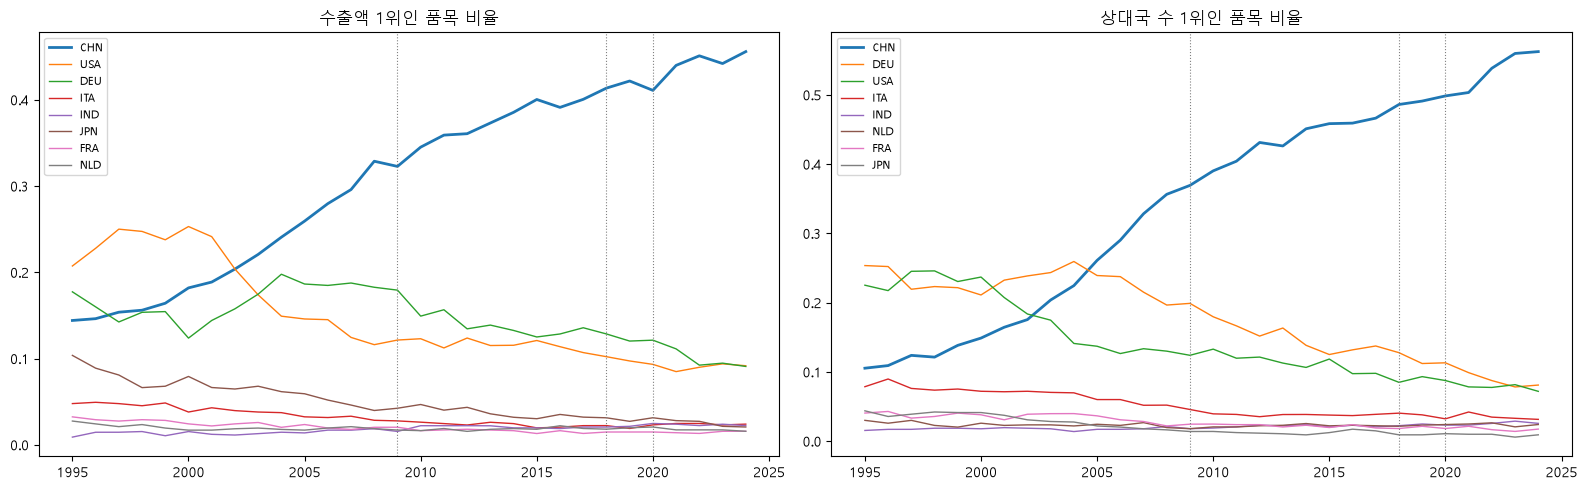

In [8]:
# 그림 2 — 1위인 품목 비율의 추이
FOCUS = ["CHN", "USA", "DEU", "JPN", "ITA", "FRA", "NLD", "KOR", "TWN", "IND", "VNM", "MEX"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (tab, ttl) in zip(axes, [(cnt, "수출액 1위인 품목 비율"), (cntd, "상대국 수 1위인 품목 비율")]):
    cols = sorted([c for c in FOCUS if c in tab.columns], key=lambda c: -tab[c].iloc[-1])[:8]
    for c in cols:
        ax.plot(tab.index, tab[c], label=c, lw=2 if c == "CHN" else 1)
    ax.set_title(ttl); ax.legend(fontsize=8)
    for y in (2009, 2018, 2020):
        ax.axvline(y, color="gray", ls=":", lw=0.8)
fig.tight_layout(); fig.savefig(IMG / "fig2_1위수출국_정체.png", dpi=110, facecolor="white"); plt.show()

### 수출 HHI 변화의 국가별 분해와 중국 제외 HHI

품목마다 1995–97년 평균 점유율과 2022–24년 평균 점유율로 $`\Delta H = \sum_i (s_{i,1}^2 - s_{i,0}^2)`$를 나라별로 나눈다. 중국 제외 HHI는 중국을 빼고 남은 수출국들 사이에서 점유율을 다시 정규화해 계산한다.

품목 평균 HHI 0.1879 → 0.1887 (변화 +0.0007), 오른 품목 비율 45%


,품목 평균 기여
iso,
CHN,0.0559
IDN,0.0021
IND,0.0019
VNM,0.0017
TUR,0.0015
COD,0.0013
USA,-0.0188
DEU,-0.0117
JPN,-0.0081


중국 점유율 품목 중위(없는 해 0): 1995 0.018, 2000 0.031, 2005 0.061, 2010 0.098, 2015 0.130, 2019 0.130, 2024 0.158


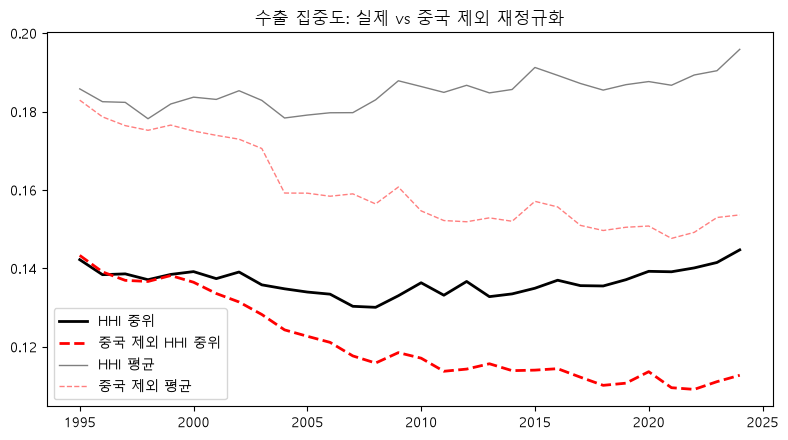

hhi        hhi_ex       
     median   mean median   mean
t                               
1995  0.142  0.186  0.143  0.183
2000  0.139  0.184  0.136  0.175
2005  0.134  0.179  0.123  0.159
2010  0.136  0.186  0.117  0.155
2015  0.135  0.191  0.114  0.157
2019  0.137  0.187  0.111  0.150
2024  0.145  0.196  0.113  0.154

In [9]:
def period_shares(y0, y1):
    return ex[ex.t.between(y0, y1)].groupby(["code", "iso"]).s.mean()

both = pd.concat([period_shares(1995, 1997).rename("s0"), period_shares(2022, 2024).rename("s1")], axis=1).fillna(0.0)
both["contrib"] = both.s1 ** 2 - both.s0 ** 2
hhi0 = (both.s0 ** 2).groupby(level="code").sum(); hhi1 = (both.s1 ** 2).groupby(level="code").sum()
dh = hhi1 - hhi0
contrib = (both.contrib.groupby(level="iso").sum() / len(dh)).sort_values()
print(f"품목 평균 HHI {hhi0.mean():.4f} → {hhi1.mean():.4f} (변화 {dh.mean():+.4f}), 오른 품목 비율 {(dh > 0).mean():.0%}")
dec = pd.concat([contrib.tail(6)[::-1], contrib.head(6)]).rename("품목 평균 기여").to_frame()
dec.to_csv(OUT / "s3_HHI_분해.csv", encoding="utf-8-sig")
display(dec.round(4))

exx = ex[ex.iso != "CHN"].copy()
exx["s"] = exx.x / exx.groupby(["t", "code"]).x.transform("sum")
hh = pd.concat([(ex.s ** 2).groupby([ex.t, ex.code]).sum().rename("hhi"),
                (exx.s ** 2).groupby([exx.t, exx.code]).sum().rename("hhi_ex")], axis=1).reset_index()
hm = hh.groupby("t")[["hhi", "hhi_ex"]].agg(["median", "mean"])
hm.to_csv(OUT / "s3_HHI_중국제외.csv", encoding="utf-8-sig")

# 중국 점유율의 품목 중위: 중국이 한 번이라도 수출한 품목에서, 수출하지 않은 해는 0으로 채운다
piv_all = ex[ex.iso == "CHN"].pivot_table(index="code", columns="t", values="s", fill_value=0.0)
chn_med0 = piv_all.median()
print("중국 점유율 품목 중위(없는 해 0):", ", ".join(f"{y} {chn_med0[y]:.3f}" for y in YRS))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hm.index, hm[("hhi", "median")], "k-", lw=2, label="HHI 중위")
ax.plot(hm.index, hm[("hhi_ex", "median")], "r--", lw=2, label="중국 제외 HHI 중위")
ax.plot(hm.index, hm[("hhi", "mean")], "k-", lw=1, alpha=0.5, label="HHI 평균")
ax.plot(hm.index, hm[("hhi_ex", "mean")], "r--", lw=1, alpha=0.5, label="중국 제외 평균")
ax.legend(); ax.set_title("수출 집중도: 실제 vs 중국 제외 재정규화")
fig.tight_layout(); fig.savefig(IMG / "fig3_HHI_중국제외.png", dpi=110, facecolor="white"); plt.show()
hm.loc[YRS].round(3)

## §5 언제부터 변화가 생기는가

### 단일 기울기 단절점과 5년 구간 변화

연도별 시계열 $`y_t`$에 연속 구간선형 $`y_t = a + b_1 (t - 1995) + b_2 \max(t - c, 0)`$를 맞추고, 오차제곱합이 가장 작은 단절 연도 $`c`$를 2000–2019년에서 고른다. 이전 기울기는 $`b_1`$, 이후 기울기는 $`b_1 + b_2`$다.

In [10]:
def break_fit(years, y, lo=2000, hi=2019):
    t = np.asarray(years, float); y = np.asarray(y, float)
    best = None
    for c in range(lo, hi + 1):
        X = np.c_[np.ones_like(t), t - t[0], np.maximum(t - c, 0)]
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        sse = ((y - X @ beta) ** 2).sum()
        if best is None or sse < best[0]:
            best = (sse, c, beta)
    sse, c, beta = best
    X0 = np.c_[np.ones_like(t), t - t[0]]
    beta0, *_ = np.linalg.lstsq(X0, y, rcond=None)
    return dict(단절연도=c, 이전기울기=beta[1], 이후기울기=beta[1] + beta[2], SSE비=sse / ((y - X0 @ beta0) ** 2).sum())


years = sorted(ex.t.unique())
chn = ex[ex.iso == "CHN"]
S = pd.DataFrame(index=years)
S["top1_share"] = top.groupby("t").iso.apply(lambda s: (s == "CHN").mean())
S["topdeg_share"] = topd.groupby("t").iso.apply(lambda s: (s == "CHN").mean())
S["chn_median_share"] = chn.groupby("t").s.median()
S["chn_mean_share"] = chn.groupby("t").s.mean()
xm = con.execute("""SELECT t, code, hhi_exp, top5_exp_share, modularity, centralization_out, intra_region_share, gini_out_strength
    FROM mart_net_metrics WHERE level='hs4' AND variant='w1m_bal_xchn'""").df()
for c in ["hhi_exp", "top5_exp_share", "modularity", "centralization_out", "intra_region_share", "gini_out_strength"]:
    S[f"x_{c}"] = xm.groupby("t")[c].median()
S.to_csv(OUT / "s5_계열.csv", encoding="utf-8-sig")
NAMES = {"top1_share": "중국이 1위 수출국인 품목 비율", "topdeg_share": "중국이 최대 연결국인 품목 비율",
         "chn_median_share": "중국 점유율 품목 중위", "chn_mean_share": "중국 점유율 품목 평균",
         "x_hhi_exp": "중국 제외 HHI 중위", "x_top5_exp_share": "중국 제외 상위 5개국 점유율 중위",
         "x_modularity": "중국 제외 모듈성 중위", "x_centralization_out": "중국 제외 차수 중심화 중위",
         "x_intra_region_share": "중국 제외 역내 비중 중위", "x_gini_out_strength": "중국 제외 수출 지니 중위"}
BRK = pd.DataFrame({NAMES[c]: break_fit(S.index, S[c]) for c in NAMES}).T
BRK.to_csv(OUT / "s5_단절점.csv", encoding="utf-8-sig")
display(BRK.round(4))

five = []
for a_, b_ in [(1995, 2000), (2000, 2005), (2005, 2010), (2010, 2015), (2015, 2019), (2019, 2024)]:
    d = S.loc[b_] - S.loc[a_]
    five.append(dict(구간=f"{a_}→{b_}", 일위_비율=d.top1_share, 최대연결_비율=d.topdeg_share, 점유율_중위=d.chn_median_share,
                     중국제외_HHI=d.x_hhi_exp, 중국제외_모듈성=d.x_modularity, 중국제외_상위5=d.x_top5_exp_share))
pd.DataFrame(five).set_index("구간").round(4)

,단절연도,이전기울기,이후기울기,SSE비
중국이 1위 수출국인 품목 비율,2012.0,0.0147,0.0074,0.3243
중국이 최대 연결국인 품목 비율,2012.0,0.0208,0.0114,0.4365
중국 점유율 품목 중위,2015.0,0.0061,0.0034,0.5251
중국 점유율 품목 평균,2011.0,0.0065,0.0024,0.1329
중국 제외 HHI 중위,2008.0,-0.0022,-0.0005,0.1820
중국 제외 상위 5개국 점유율 중위,2010.0,-0.0059,-0.0009,0.1840
중국 제외 모듈성 중위,2012.0,0.0017,-0.0008,0.2974
중국 제외 차수 중심화 중위,2001.0,-0.0023,0.0009,0.6519
중국 제외 역내 비중 중위,2004.0,0.0025,-0.0012,0.5468
중국 제외 수출 지니 중위,2012.0,0.0013,0.0000,0.6586


,일위_비율,최대연결_비율,점유율_중위,중국제외_HHI,중국제외_모듈성,중국제외_상위5
구간,,,,,,
1995→2000,0.0378,0.0435,0.0136,-0.0071,0.0153,-0.0181
2000→2005,0.0774,0.1122,0.0350,-0.0150,0.0042,-0.0433
2005→2010,0.0858,0.1292,0.0303,-0.0066,0.0128,-0.0188
2010→2015,0.0552,0.0682,0.0373,-0.0032,-0.0027,-0.0058
2015→2019,0.0214,0.0326,-0.0006,-0.0028,-0.0013,-0.0095
2019→2024,0.0341,0.0714,0.0290,0.0017,-0.0079,0.0035


,획득,상실,순증,구간끝_1위_품목
구간,,,,
1995→2000,103,56,47,225
2000→2005,160,65,95,320
2005→2010,188,87,101,421
2010→2015,160,91,69,490
2015→2019,116,94,22,512
2019→2024,186,146,40,552


2019년 1위였다가 2024년 1위가 아닌 품목 37개. 1위를 가져간 나라: ITA 4, DEU 4, VNM 3, USA 2, IND 2, MAR 2, BRA 2, BGD 2


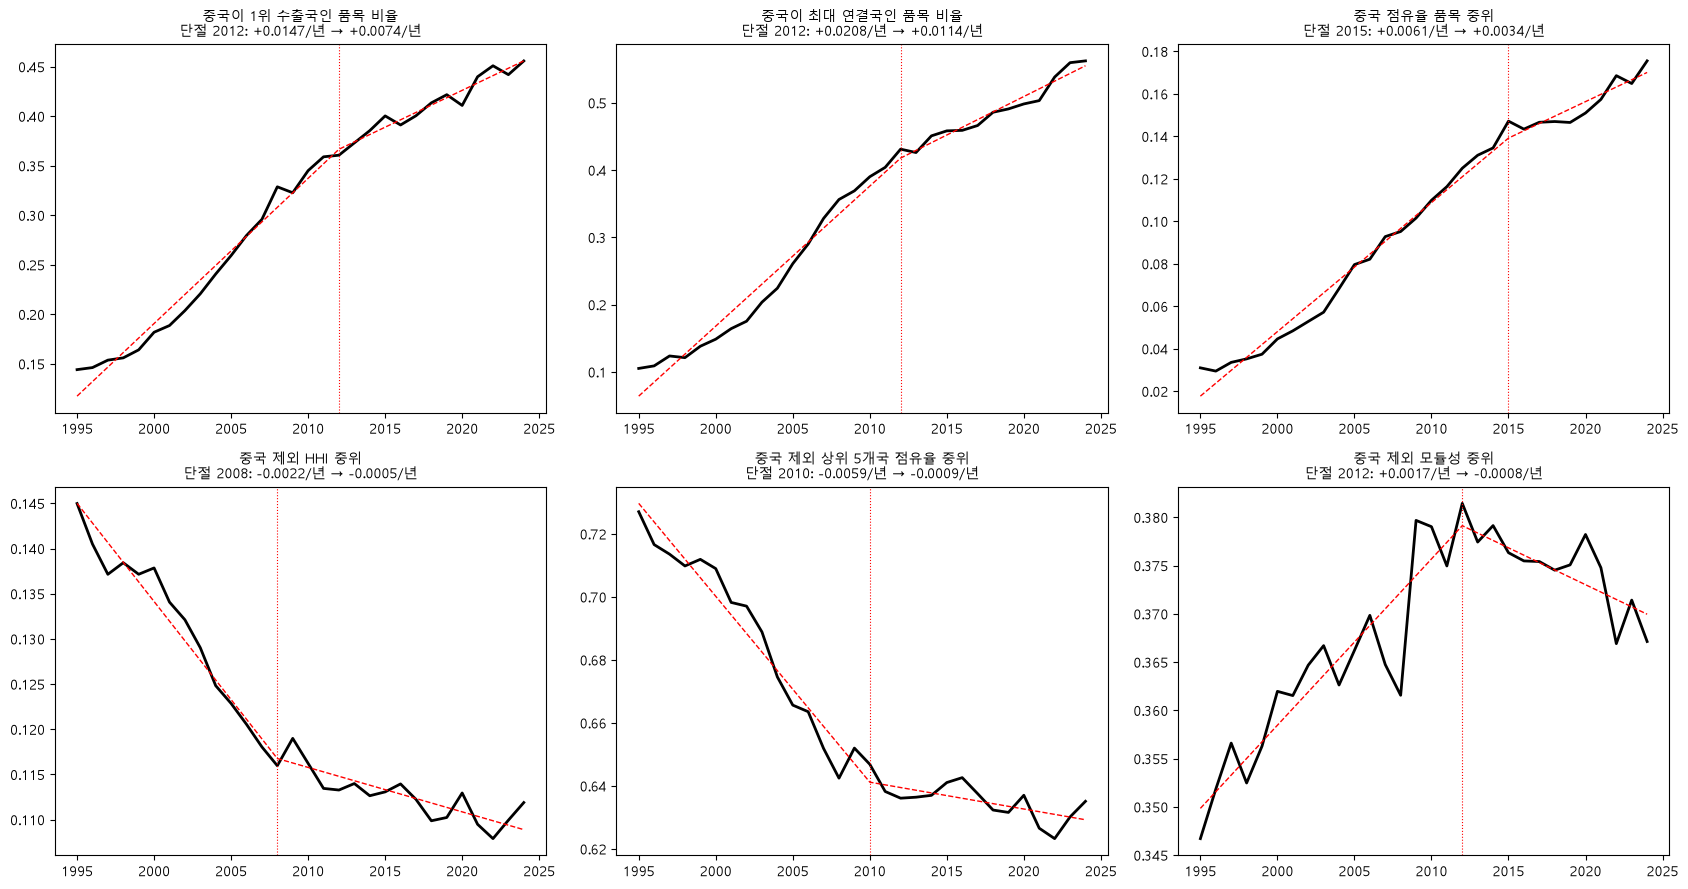

In [11]:
# 중국의 1위 지위 획득·상실
t1 = top.set_index(["t", "code"]).iso.unstack("t")
isc = (t1 == "CHN")
gl = []
for a_, b_ in [(1995, 2000), (2000, 2005), (2005, 2010), (2010, 2015), (2015, 2019), (2019, 2024)]:
    gain = sum(int((isc[y] & ~isc[y - 1]).sum()) for y in range(a_ + 1, b_ + 1))
    lose = sum(int((~isc[y] & isc[y - 1]).sum()) for y in range(a_ + 1, b_ + 1))
    gl.append(dict(구간=f"{a_}→{b_}", 획득=gain, 상실=lose, 순증=gain - lose, 구간끝_1위_품목=int(isc[b_].sum())))
GL = pd.DataFrame(gl).set_index("구간")
display(GL)
lost = isc.index[isc[2019] & ~isc[2024]]
who = top[top.t == 2024].set_index("code").iso.reindex(lost).value_counts()
print(f"2019년 1위였다가 2024년 1위가 아닌 품목 {len(lost)}개. 1위를 가져간 나라:", ", ".join(f"{k} {v}" for k, v in who.head(8).items()))

# 그림 5 — 계열 여섯과 단절점
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, c in zip(axes.flat, ["top1_share", "topdeg_share", "chn_median_share", "x_hhi_exp", "x_top5_exp_share", "x_modularity"]):
    f = BRK.loc[NAMES[c]]; b = int(f.단절연도)
    t = np.array(S.index, float)
    X = np.c_[np.ones_like(t), t - t[0], np.maximum(t - b, 0)]
    beta, *_ = np.linalg.lstsq(X, S[c].values, rcond=None)
    ax.plot(S.index, S[c], "k-", lw=2); ax.plot(S.index, X @ beta, "r--", lw=1); ax.axvline(b, color="r", ls=":", lw=0.8)
    ax.set_title(f"{NAMES[c]}\n단절 {b}: {f.이전기울기:+.4f}/년 → {f.이후기울기:+.4f}/년", fontsize=10)
fig.tight_layout(); fig.savefig(IMG / "fig5_전환점.png", dpi=110, facecolor="white"); plt.show()

### 품목별 중국 점유율의 정점

중국 점유율의 3년 이동평균이 정점을 찍은 해를 품목마다 구한다. 점유율이 한 번이라도 5%를 넘은 호만 쓴다. 2024년 값이 정점의 90% 아래이고 정점이 2021년 이전이면 "정점 통과", 정점이 2022년 이후면 "아직 상승 중"으로 본다.

5% 경험 1015개 호. 정점 통과 415개 (41%), 아직 상승 중 472개 (47%)


,품목,정점연도_중위,정점통과,상승중,점유율_2024_중위
부,,,,,
동물성 생산품,25,2007.0,0.920,0.040,0.064
광물성 생산품,38,2008.0,0.763,0.158,0.061
목재·코르크,20,2013.5,0.750,0.050,0.113
식품·음료·담배,28,2007.0,0.750,0.250,0.093
예술품·기타,3,2012.0,0.667,0.000,0.018
신발·모자,20,2011.5,0.650,0.150,0.521
귀금속·보석,11,2013.0,0.636,0.364,0.167
가죽·모피,19,2016.0,0.632,0.316,0.147
식물성 생산품,47,2011.0,0.617,0.298,0.082


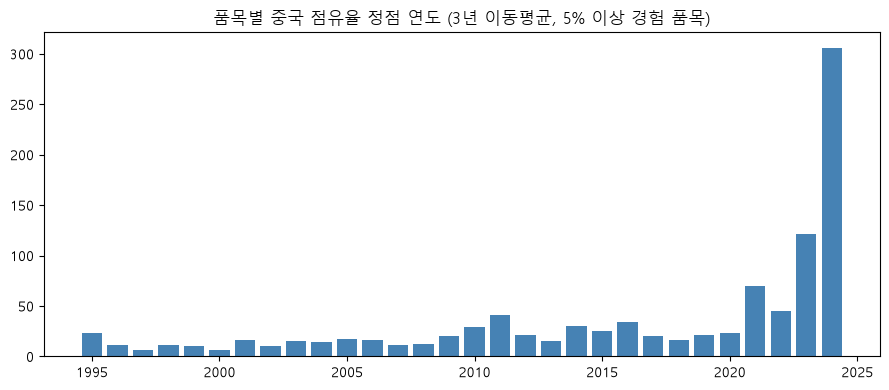

In [12]:
sec4 = con.execute("SELECT DISTINCT hs4, section_name FROM dim_product").df().drop_duplicates("hs4").set_index("hs4").section_name
piv = chn.pivot_table(index="code", columns="t", values="s", fill_value=0.0).reindex(columns=years, fill_value=0.0)
ma = piv.T.rolling(3, center=True, min_periods=2).mean().T
peak_year = ma.idxmax(axis=1); peak_val = ma.max(axis=1); last = ma[years[-1]]
ever = peak_val >= 0.05
past = (last < 0.9 * peak_val) & (peak_year <= 2021) & ever
rising = (peak_year >= 2022) & ever
pk = pd.DataFrame({"정점연도": peak_year, "정점": peak_val, "2024": last, "정점통과": past, "5%경험": ever})
pk["부"] = pk.index.map(sec4)
pk.to_csv(OUT / "s5_품목별_정점.csv", encoding="utf-8-sig")
print(f"5% 경험 {int(ever.sum())}개 호. 정점 통과 {int(past.sum())}개 ({past.sum() / ever.sum():.0%}), "
      f"아직 상승 중 {int(rising.sum())}개 ({rising.sum() / ever.sum():.0%})")
bysec = pk[ever].groupby("부").agg(품목=("정점연도", "size"), 정점연도_중위=("정점연도", "median"),
                                   정점통과=("정점통과", "mean"), 상승중=("정점연도", lambda s: (s >= 2022).mean()),
                                   점유율_2024_중위=("2024", "median")).sort_values("정점통과", ascending=False)
bysec.to_csv(OUT / "s5_부별_정점.csv", encoding="utf-8-sig")
display(bysec.round(3))

hist = pk[ever].정점연도.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(hist.index, hist.values, color="steelblue"); ax.set_title("품목별 중국 점유율 정점 연도 (3년 이동평균, 5% 이상 경험 품목)")
fig.tight_layout(); fig.savefig(IMG / "fig6_품목별_정점연도.png", dpi=110, facecolor="white"); plt.show()

## 보고서 수치 대조

보고서가 인용한 수치를 위에서 다시 계산한 값과 맞대 본다. 보고서는 소수 둘째 자리(β/SD)나 셋째 자리(비율)까지 적었으므로 허용 오차를 그만큼 둔다. 하나라도 어긋나면 이 셀이 멈춘다.

In [13]:
A_ = {tag: r["A"].set_index("metric") for tag, r in RES.items()}
chk = [
    ("§2 HS4 중위 활성 국가 1995", med.loc["n_nodes", ("w1m_bal", 1995)], 50, 0.5),
    ("§2 HS4 중위 활성 국가 2024", med.loc["n_nodes", ("w1m_bal", 2024)], 81, 0.5),
    ("§2 HS4 중위 차수 중심화 1995", med.loc["centralization_out", ("w1m_bal", 1995)], 0.433, 0.0006),
    ("§2 HS4 중위 차수 중심화 2024", med.loc["centralization_out", ("w1m_bal", 2024)], 0.583, 0.0006),
    ("§2 추세 차수 중심화", A_["hs4_w1m_bal"].loc["centralization_out", "beta_SD"], 0.24, 0.006),
    ("§2 추세 수출 지니", A_["hs4_w1m_bal"].loc["gini_out_strength", "beta_SD"], 0.26, 0.006),
    ("§2 추세 역내 비중", A_["hs4_w1m_bal"].loc["intra_region_share", "beta_SD"], -0.13, 0.006),
    ("§2 추세 밀도", A_["hs4_w1m_bal"].loc["density", "beta_SD"], -0.17, 0.006),
    ("§4 중국 제외 차수 중심화", A_["hs4_w1m_bal_xchn"].loc["centralization_out", "beta_SD"], 0.00, 0.006),
    ("§4 중국 제외 수출 HHI", A_["hs4_w1m_bal_xchn"].loc["hhi_exp", "beta_SD"], -0.11, 0.006),
    ("§4 중국 제외 모듈성", A_["hs4_w1m_bal_xchn"].loc["modularity", "beta_SD"], 0.06, 0.006),
    ("§4 중국 제외 상위 5개국", A_["hs4_w1m_bal_xchn"].loc["top5_exp_share", "beta_SD"], -0.18, 0.006),
    ("§4 HS2 중국 제외 차수 중심화", A_["hs2_w1m_bal_xchn"].loc["centralization_out", "beta_SD"], 0.11, 0.006),
    ("§3 중국 1위 품목 비율 1995", cnt.loc[1995, "CHN"], 0.144, 0.0006),
    ("§3 중국 1위 품목 비율 2024", cnt.loc[2024, "CHN"], 0.456, 0.0006),
    ("§3 중국 최대 연결 품목 비율 1995", cntd.loc[1995, "CHN"], 0.105, 0.0006),
    ("§3 중국 최대 연결 품목 비율 2024", cntd.loc[2024, "CHN"], 0.562, 0.0006),
    ("§3 HHI 분해 중국 기여", contrib["CHN"], 0.0559, 0.00006),
    ("§3 중국 점유율 품목 중위 1995", chn_med0[1995], 0.018, 0.0006),
    ("§3 중국 점유율 품목 중위 2024", chn_med0[2024], 0.158, 0.0006),
    ("§5.1 단절 1위 품목 비율", BRK.loc[NAMES["top1_share"], "단절연도"], 2012, 0),
    ("§5.1 단절 최대 연결 품목 비율", BRK.loc[NAMES["topdeg_share"], "단절연도"], 2012, 0),
    ("§5.1 단절 점유율 중위", BRK.loc[NAMES["chn_median_share"], "단절연도"], 2015, 0),
    ("§5.3 단절 중국 제외 HHI", BRK.loc[NAMES["x_hhi_exp"], "단절연도"], 2008, 0),
    ("§5.3 단절 중국 제외 상위 5개국", BRK.loc[NAMES["x_top5_exp_share"], "단절연도"], 2010, 0),
    ("§5.3 단절 중국 제외 모듈성", BRK.loc[NAMES["x_modularity"], "단절연도"], 2012, 0),
    ("§5.1 2019→2024 1위 획득", GL.loc["2019→2024", "획득"], 186, 0),
    ("§5.1 2019→2024 1위 상실", GL.loc["2019→2024", "상실"], 146, 0),
    ("§5.2 5% 경험 호", int(ever.sum()), 1015, 0),
    ("§5.2 정점 통과 호", int(past.sum()), 415, 0),
    ("§5.2 아직 상승 중 호", int(rising.sum()), 472, 0),
    ("VI장 실질 임곗값 활성 국가 2024", med.loc["n_nodes", ("w1m_bal_real", 2024)], 66, 0.5),
    ("부록 B 실질 임곗값 차수 중심화", A_["hs4_w1m_bal_real"].loc["centralization_out", "beta_SD"], 0.20, 0.006),
    ("부록 B 실질 임곗값 최대 k-코어", A_["hs4_w1m_bal_real"].loc["max_kcore", "beta_SD"], 0.12, 0.006),
    ("부록 B 실질 임곗값 수출 HHI", A_["hs4_w1m_bal_real"].loc["hhi_exp", "beta_SD"], 0.07, 0.006),
    ("IV장 중국 제외 실질 수출 지니", A_["hs4_w1m_bal_xchn_real"].loc["gini_out_strength", "beta_SD"], 0.01, 0.006),
    ("IV장 중국 제외 실질 수출 HHI", A_["hs4_w1m_bal_xchn_real"].loc["hhi_exp", "beta_SD"], -0.06, 0.006),
    ("IV장 중국 제외 실질 모듈성", A_["hs4_w1m_bal_xchn_real"].loc["modularity", "beta_SD"], 0.07, 0.006),
]
CHK = pd.DataFrame(chk, columns=["항목", "계산값", "보고서", "허용오차"])
CHK["일치"] = (CHK.계산값.astype(float) - CHK.보고서).abs() <= CHK.허용오차 + 1e-12
display(CHK)
assert CHK.일치.all(), "보고서와 어긋나는 수치가 있다: " + ", ".join(CHK.loc[~CHK.일치, "항목"])
print(f"보고서 수치 {len(CHK)}건 모두 일치")

,항목,계산값,보고서,허용오차,일치
0,§2 HS4 중위 활성 국가 1995,50.000000,50.0000,0.50000,True
1,§2 HS4 중위 활성 국가 2024,81.000000,81.0000,0.50000,True
2,§2 HS4 중위 차수 중심화 1995,0.433318,0.4330,0.00060,True
3,§2 HS4 중위 차수 중심화 2024,0.583333,0.5830,0.00060,True
4,§2 추세 차수 중심화,0.235838,0.2400,0.00600,True
5,§2 추세 수출 지니,0.262205,0.2600,0.00600,True
6,§2 추세 역내 비중,-0.127999,-0.1300,0.00600,True
7,§2 추세 밀도,-0.168944,-0.1700,0.00600,True
8,§4 중국 제외 차수 중심화,0.002826,0.0000,0.00600,True
9,§4 중국 제외 수출 HHI,-0.109714,-0.1100,0.00600,True


보고서 수치 38건 모두 일치
